In [1]:
print("Traffic Forecasting project started!")

Traffic Forecasting project started!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/TrafficTwoMonth.csv")

df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,13,2,2,24,41,normal
1,12:15:00 AM,10,Tuesday,14,1,1,36,52,normal
2,12:30:00 AM,10,Tuesday,10,2,2,32,46,normal
3,12:45:00 AM,10,Tuesday,10,2,2,36,50,normal
4,1:00:00 AM,10,Tuesday,11,2,1,34,48,normal


In [4]:
df.shape

(5952, 9)

In [5]:
df.columns

Index(['Time', 'Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount',
       'TruckCount', 'Total', 'Traffic Situation'],
      dtype='str')

In [6]:
df.dtypes

Time                   str
Date                 int64
Day of the week        str
CarCount             int64
BikeCount            int64
BusCount             int64
TruckCount           int64
Total                int64
Traffic Situation      str
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5952 entries, 0 to 5951
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Time               5952 non-null   str  
 1   Date               5952 non-null   int64
 2   Day of the week    5952 non-null   str  
 3   CarCount           5952 non-null   int64
 4   BikeCount          5952 non-null   int64
 5   BusCount           5952 non-null   int64
 6   TruckCount         5952 non-null   int64
 7   Total              5952 non-null   int64
 8   Traffic Situation  5952 non-null   str  
dtypes: int64(6), str(3)
memory usage: 418.6 KB


In [8]:
df.isnull().sum()

Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,5952.000000,5952.000000,5952.000000,5952.000000,5952.000000,5952.000000
mean,16.000000,65.440692,12.161458,12.912970,18.646337,109.161458
std,8.945023,44.749335,11.537944,12.497736,10.973139,55.996312
min,1.000000,5.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,18.750000,3.000000,2.000000,10.000000,54.000000
50%,16.000000,62.000000,9.000000,10.000000,18.000000,104.000000
75%,24.000000,103.000000,19.000000,20.000000,27.000000,153.000000
max,31.000000,180.000000,70.000000,50.000000,60.000000,279.000000


In [11]:
df["Traffic Situation"].value_counts()

Traffic Situation
normal    3610
heavy     1137
low        834
high       371
Name: count, dtype: int64

In [12]:
df["Day of the week"].value_counts()

Day of the week
Tuesday      960
Wednesday    960
Thursday     960
Friday       768
Saturday     768
Sunday       768
Monday       768
Name: count, dtype: int64

In [13]:
df["Date"].unique()

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31,  1,  2,  3,  4,  5,  6,  7,  8,  9])

In [14]:
df.head(10)

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,13,2,2,24,41,normal
1,12:15:00 AM,10,Tuesday,14,1,1,36,52,normal
2,12:30:00 AM,10,Tuesday,10,2,2,32,46,normal
3,12:45:00 AM,10,Tuesday,10,2,2,36,50,normal
4,1:00:00 AM,10,Tuesday,11,2,1,34,48,normal
5,1:15:00 AM,10,Tuesday,15,1,1,39,56,normal
6,1:30:00 AM,10,Tuesday,14,2,2,27,45,normal
7,1:45:00 AM,10,Tuesday,13,2,1,20,36,normal
8,2:00:00 AM,10,Tuesday,7,0,0,26,33,normal
9,2:15:00 AM,10,Tuesday,13,0,0,34,47,normal


In [15]:
df.tail(10)

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
5942,9:30:00 PM,9,Thursday,106,18,13,27,164,normal
5943,9:45:00 PM,9,Thursday,107,14,10,18,149,normal
5944,10:00:00 PM,9,Thursday,17,4,1,20,42,normal
5945,10:15:00 PM,9,Thursday,11,4,1,30,46,normal
5946,10:30:00 PM,9,Thursday,11,4,0,23,38,normal
5947,10:45:00 PM,9,Thursday,16,3,1,36,56,normal
5948,11:00:00 PM,9,Thursday,11,0,1,30,42,normal
5949,11:15:00 PM,9,Thursday,15,4,1,25,45,normal
5950,11:30:00 PM,9,Thursday,16,5,0,27,48,normal
5951,11:45:00 PM,9,Thursday,14,3,1,15,33,low


In [16]:
df[["Time", "Date", "Day of the week"]].iloc[90:105]

,Time,Date,Day of the week
90,10:30:00 PM,10,Tuesday
91,10:45:00 PM,10,Tuesday
92,11:00:00 PM,10,Tuesday
93,11:15:00 PM,10,Tuesday
94,11:30:00 PM,10,Tuesday
95,11:45:00 PM,10,Tuesday
96,12:00:00 AM,11,Wednesday
97,12:15:00 AM,11,Wednesday
98,12:30:00 AM,11,Wednesday
99,12:45:00 AM,11,Wednesday


In [17]:
df[["Time", "Date", "Day of the week"]].iloc[2970:2985]

,Time,Date,Day of the week
2970,10:30:00 PM,9,Thursday
2971,10:45:00 PM,9,Thursday
2972,11:00:00 PM,9,Thursday
2973,11:15:00 PM,9,Thursday
2974,11:30:00 PM,9,Thursday
2975,11:45:00 PM,9,Thursday
2976,12:00:00 AM,10,Tuesday
2977,12:15:00 AM,10,Tuesday
2978,12:30:00 AM,10,Tuesday
2979,12:45:00 AM,10,Tuesday


In [18]:
df["Time"].head(10)

0    12:00:00 AM
1    12:15:00 AM
2    12:30:00 AM
3    12:45:00 AM
4     1:00:00 AM
5     1:15:00 AM
6     1:30:00 AM
7     1:45:00 AM
8     2:00:00 AM
9     2:15:00 AM
Name: Time, dtype: str

In [19]:
df["Time"].tail(10)

5942     9:30:00 PM
5943     9:45:00 PM
5944    10:00:00 PM
5945    10:15:00 PM
5946    10:30:00 PM
5947    10:45:00 PM
5948    11:00:00 PM
5949    11:15:00 PM
5950    11:30:00 PM
5951    11:45:00 PM
Name: Time, dtype: str

In [20]:
df.iloc[[95, 96, 191, 192, 2975, 2976]][
    ["Time", "Date", "Day of the week"]
]

,Time,Date,Day of the week
95,11:45:00 PM,10,Tuesday
96,12:00:00 AM,11,Wednesday
191,11:45:00 PM,11,Wednesday
192,12:00:00 AM,12,Thursday
2975,11:45:00 PM,9,Thursday
2976,12:00:00 AM,10,Tuesday


In [21]:
df.groupby("Date").size()

Date
1     192
2     192
3     192
4     192
5     192
6     192
7     192
8     192
9     192
10    192
11    192
12    192
13    192
14    192
15    192
16    192
17    192
18    192
19    192
20    192
21    192
22    192
23    192
24    192
25    192
26    192
27    192
28    192
29    192
30    192
31    192
dtype: int64

In [22]:
df["Timestamp"] = pd.date_range(
    start="2024-01-01 00:00:00",
    periods=len(df),
    freq="15min"
)

df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,Timestamp
0,12:00:00 AM,10,Tuesday,13,2,2,24,41,normal,2024-01-01 00:00:00
1,12:15:00 AM,10,Tuesday,14,1,1,36,52,normal,2024-01-01 00:15:00
2,12:30:00 AM,10,Tuesday,10,2,2,32,46,normal,2024-01-01 00:30:00
3,12:45:00 AM,10,Tuesday,10,2,2,36,50,normal,2024-01-01 00:45:00
4,1:00:00 AM,10,Tuesday,11,2,1,34,48,normal,2024-01-01 01:00:00


In [23]:
df[["Timestamp", "Time", "Date", "Day of the week"]].head(10)

,Timestamp,Time,Date,Day of the week
0,2024-01-01 00:00:00,12:00:00 AM,10,Tuesday
1,2024-01-01 00:15:00,12:15:00 AM,10,Tuesday
2,2024-01-01 00:30:00,12:30:00 AM,10,Tuesday
3,2024-01-01 00:45:00,12:45:00 AM,10,Tuesday
4,2024-01-01 01:00:00,1:00:00 AM,10,Tuesday
5,2024-01-01 01:15:00,1:15:00 AM,10,Tuesday
6,2024-01-01 01:30:00,1:30:00 AM,10,Tuesday
7,2024-01-01 01:45:00,1:45:00 AM,10,Tuesday
8,2024-01-01 02:00:00,2:00:00 AM,10,Tuesday
9,2024-01-01 02:15:00,2:15:00 AM,10,Tuesday


In [24]:
df[["Timestamp", "Time", "Date", "Day of the week"]].tail(10)

,Timestamp,Time,Date,Day of the week
5942,2024-03-02 21:30:00,9:30:00 PM,9,Thursday
5943,2024-03-02 21:45:00,9:45:00 PM,9,Thursday
5944,2024-03-02 22:00:00,10:00:00 PM,9,Thursday
5945,2024-03-02 22:15:00,10:15:00 PM,9,Thursday
5946,2024-03-02 22:30:00,10:30:00 PM,9,Thursday
5947,2024-03-02 22:45:00,10:45:00 PM,9,Thursday
5948,2024-03-02 23:00:00,11:00:00 PM,9,Thursday
5949,2024-03-02 23:15:00,11:15:00 PM,9,Thursday
5950,2024-03-02 23:30:00,11:30:00 PM,9,Thursday
5951,2024-03-02 23:45:00,11:45:00 PM,9,Thursday


In [25]:
df["Timestamp"].diff().value_counts()

Timestamp
0 days 00:15:00    5951
Name: count, dtype: int64

In [26]:
df[["CarCount", "BikeCount", "BusCount", "TruckCount", "Total"]].mean()

CarCount       65.440692
BikeCount      12.161458
BusCount       12.912970
TruckCount     18.646337
Total         109.161458
dtype: float64

In [27]:
df[["CarCount", "BikeCount", "BusCount", "TruckCount", "Total"]].max()

CarCount      180
BikeCount      70
BusCount       50
TruckCount     60
Total         279
dtype: int64

In [28]:
df[["CarCount", "BikeCount", "BusCount", "TruckCount", "Total"]].min()

CarCount       5
BikeCount      0
BusCount       0
TruckCount     0
Total         21
dtype: int64

In [29]:
df["Calculated_Total"] = (
    df["CarCount"]
    + df["BikeCount"]
    + df["BusCount"]
    + df["TruckCount"]
)

(df["Total"] == df["Calculated_Total"]).value_counts()

True    5952
Name: count, dtype: int64

In [30]:
df["Hour"] = df["Timestamp"].dt.hour

In [31]:
df.groupby("Hour")["Total"].mean()

Hour
0      42.762097
1      42.419355
2      43.290323
3      44.524194
4      98.036290
5     113.012097
6     163.798387
7     163.415323
8     164.899194
9     120.975806
10    113.919355
11    102.266129
12    102.907258
13    118.431452
14    120.987903
15    118.790323
16    177.314516
17    175.939516
18    158.213710
19    119.806452
20    118.766129
21    110.540323
22     42.588710
23     42.270161
Name: Total, dtype: float64

In [32]:
df.groupby("Day of the week")["Total"].mean()

Day of the week
Friday       106.283854
Monday       108.822917
Saturday     110.080729
Sunday       109.636719
Thursday     109.452083
Tuesday      109.252083
Wednesday    110.237500
Name: Total, dtype: float64

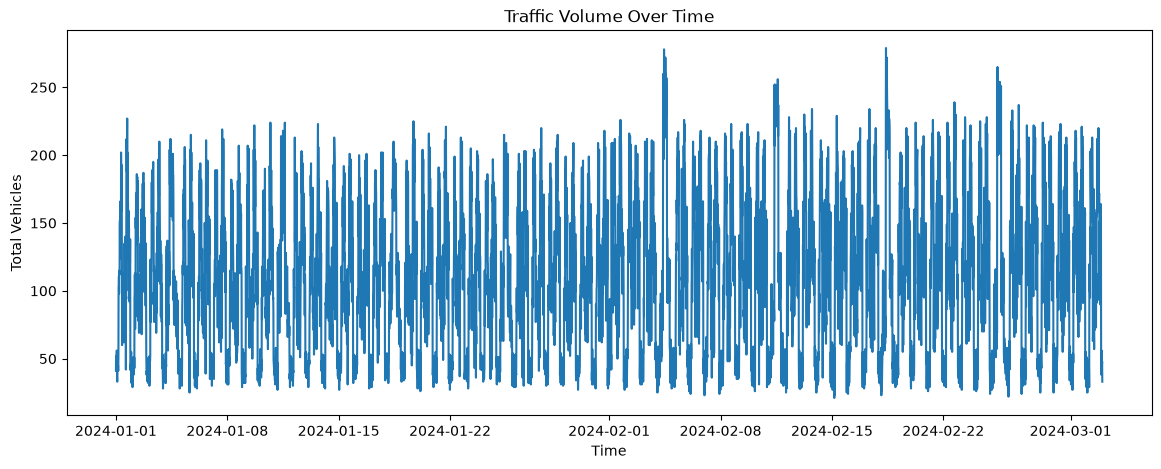

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(df["Timestamp"], df["Total"])

plt.xlabel("Time")
plt.ylabel("Total Vehicles")
plt.title("Traffic Volume Over Time")

plt.show()

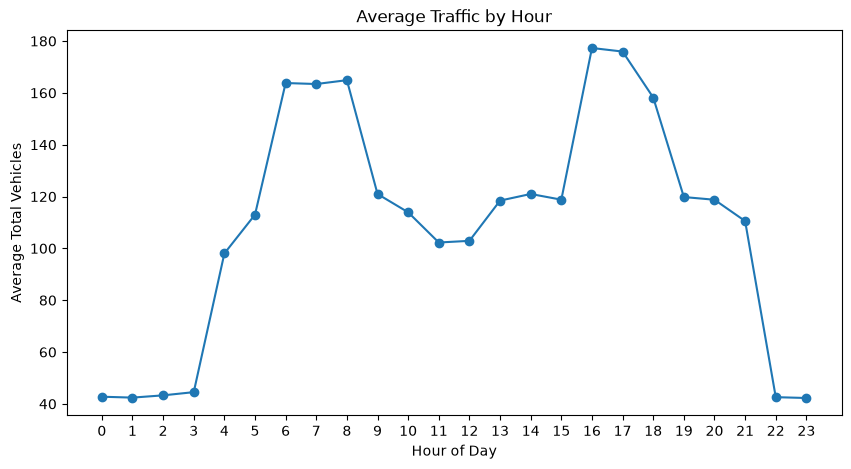

In [34]:
hourly_traffic = df.groupby("Hour")["Total"].mean()

plt.figure(figsize=(10, 5))

plt.plot(hourly_traffic.index, hourly_traffic.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Total Vehicles")
plt.title("Average Traffic by Hour")

plt.xticks(range(24))

plt.show()

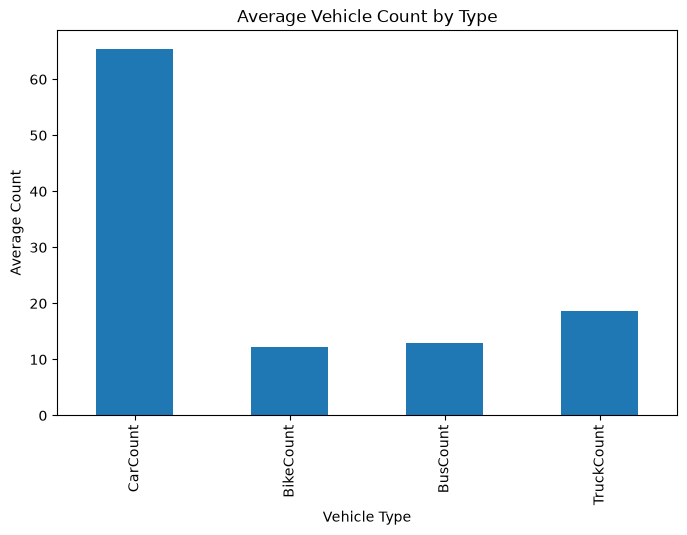

In [35]:
vehicle_means = df[
    ["CarCount", "BikeCount", "BusCount", "TruckCount"]
].mean()

plt.figure(figsize=(8, 5))

vehicle_means.plot(kind="bar")

plt.xlabel("Vehicle Type")
plt.ylabel("Average Count")
plt.title("Average Vehicle Count by Type")

plt.show()

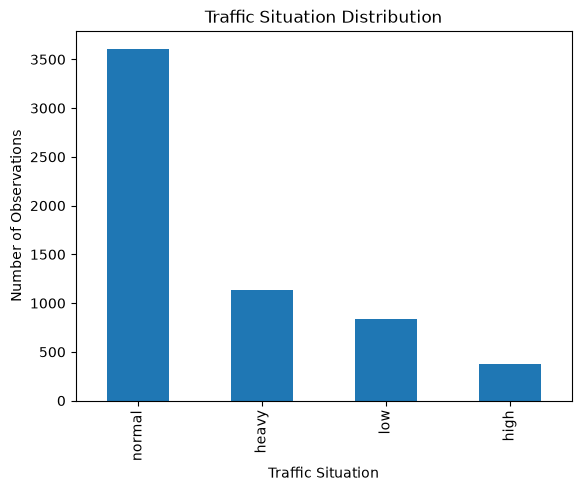

In [36]:
df["Traffic Situation"].value_counts().plot(kind="bar")

plt.xlabel("Traffic Situation")
plt.ylabel("Number of Observations")
plt.title("Traffic Situation Distribution")

plt.show()

In [37]:
weekday_traffic = df.groupby("Day of the week")["Total"].mean()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_traffic = weekday_traffic.reindex(weekday_order)

weekday_traffic

Day of the week
Monday       108.822917
Tuesday      109.252083
Wednesday    110.237500
Thursday     109.452083
Friday       106.283854
Saturday     110.080729
Sunday       109.636719
Name: Total, dtype: float64

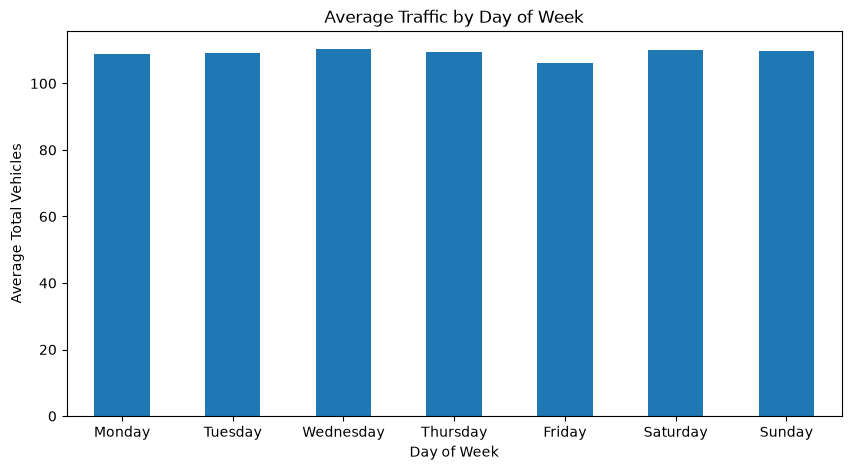

In [38]:
plt.figure(figsize=(10, 5))

weekday_traffic.plot(kind="bar")

plt.xlabel("Day of Week")
plt.ylabel("Average Total Vehicles")
plt.title("Average Traffic by Day of Week")

plt.xticks(rotation=0)

plt.show()

In [39]:
df.groupby("Traffic Situation")["Total"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Traffic Situation,,,,
heavy,1137,194.031662,168,279
high,371,139.609164,112,166
low,834,69.261391,21,167
normal,3610,88.519668,26,223


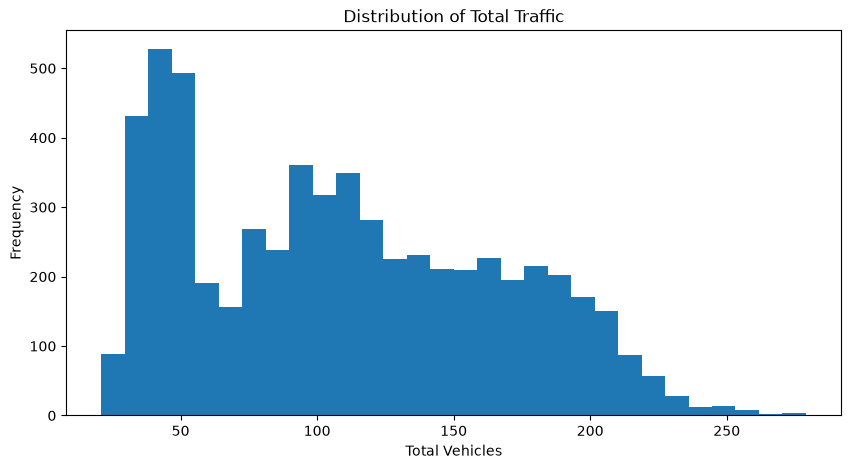

In [40]:
plt.figure(figsize=(10, 5))

plt.hist(df["Total"], bins=30)

plt.xlabel("Total Vehicles")
plt.ylabel("Frequency")
plt.title("Distribution of Total Traffic")

plt.show()

In [41]:
numeric_cols = [
    "CarCount",
    "BikeCount",
    "BusCount",
    "TruckCount",
    "Total"
]

correlation = df[numeric_cols].corr()

correlation

,CarCount,BikeCount,BusCount,TruckCount,Total
CarCount,1.000000,0.708243,0.658417,-0.615043,0.971507
BikeCount,0.708243,1.000000,0.577671,-0.607720,0.781879
BusCount,0.658417,0.577671,1.000000,-0.558372,0.758970
TruckCount,-0.615043,-0.607720,-0.558372,1.000000,-0.545390
Total,0.971507,0.781879,0.758970,-0.545390,1.000000


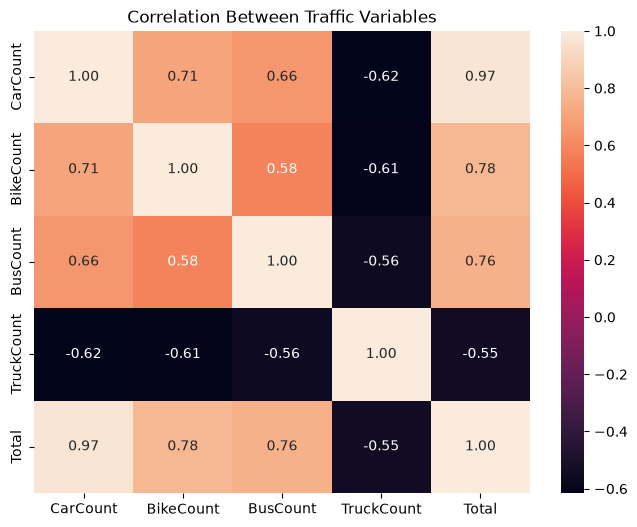

In [42]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Traffic Variables")

plt.show()

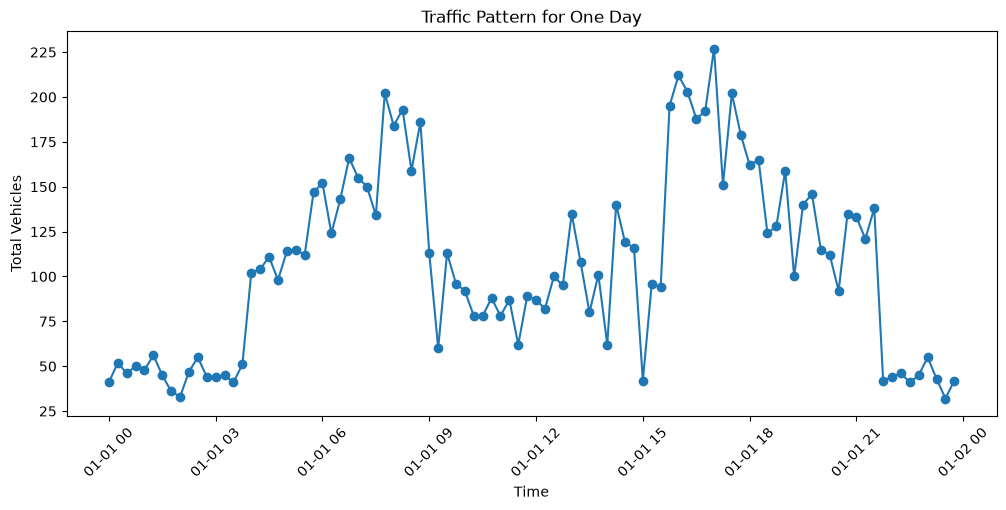

In [43]:
one_day = df.iloc[:96]

plt.figure(figsize=(12, 5))

plt.plot(one_day["Timestamp"], one_day["Total"], marker="o")

plt.xlabel("Time")
plt.ylabel("Total Vehicles")
plt.title("Traffic Pattern for One Day")

plt.xticks(rotation=45)

plt.show()

In [44]:
df["Target_15min"] = df["Total"].shift(-1)

In [45]:
df[[
    "Timestamp",
    "Total",
    "Target_15min"
]].head(10)

,Timestamp,Total,Target_15min
0,2024-01-01 00:00:00,41,52.0
1,2024-01-01 00:15:00,52,46.0
2,2024-01-01 00:30:00,46,50.0
3,2024-01-01 00:45:00,50,48.0
4,2024-01-01 01:00:00,48,56.0
5,2024-01-01 01:15:00,56,45.0
6,2024-01-01 01:30:00,45,36.0
7,2024-01-01 01:45:00,36,33.0
8,2024-01-01 02:00:00,33,47.0
9,2024-01-01 02:15:00,47,55.0


In [46]:
df[[
    "Timestamp",
    "Total",
    "Target_15min"
]].tail()

,Timestamp,Total,Target_15min
5947,2024-03-02 22:45:00,56,42.0
5948,2024-03-02 23:00:00,42,45.0
5949,2024-03-02 23:15:00,45,48.0
5950,2024-03-02 23:30:00,48,33.0
5951,2024-03-02 23:45:00,33,NaN


In [47]:
df["Target_15min"].isnull().sum()

np.int64(1)

In [48]:
df["Total_lag1"] = df["Total"].shift(1)

In [49]:
df["Total_lag2"] = df["Total"].shift(2)

In [50]:
df["Total_lag4"] = df["Total"].shift(4)

In [51]:
df["Total_lag96"] = df["Total"].shift(96)

In [52]:
df[[
    "Timestamp",
    "Total",
    "Total_lag1",
    "Total_lag2",
    "Total_lag4",
    "Total_lag96",
    "Target_15min"
]].tail(10)

,Timestamp,Total,Total_lag1,Total_lag2,Total_lag4,Total_lag96,Target_15min
5942,2024-03-02 21:30:00,164,142.0,162.0,105.0,150.0,149.0
5943,2024-03-02 21:45:00,149,164.0,142.0,90.0,158.0,42.0
5944,2024-03-02 22:00:00,42,149.0,164.0,162.0,35.0,46.0
5945,2024-03-02 22:15:00,46,42.0,149.0,142.0,40.0,38.0
5946,2024-03-02 22:30:00,38,46.0,42.0,164.0,45.0,56.0
5947,2024-03-02 22:45:00,56,38.0,46.0,149.0,55.0,42.0
5948,2024-03-02 23:00:00,42,56.0,38.0,42.0,46.0,45.0
5949,2024-03-02 23:15:00,45,42.0,56.0,46.0,39.0,48.0
5950,2024-03-02 23:30:00,48,45.0,42.0,38.0,38.0,33.0
5951,2024-03-02 23:45:00,33,48.0,45.0,56.0,29.0,NaN


In [53]:
df["Hour"] = df["Timestamp"].dt.hour

In [54]:
df["Minute"] = df["Timestamp"].dt.minute

In [55]:
day_map = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6
}

df["Weekday"] = df["Day of the week"].map(day_map)

In [56]:
df["Rush_Hour"] = (
    ((df["Hour"] >= 6) & (df["Hour"] <= 9)) |
    ((df["Hour"] >= 16) & (df["Hour"] <= 19))
).astype(int)

In [57]:
df[[
    "Timestamp",
    "Hour",
    "Minute",
    "Day of the week",
    "Weekday",
    "Rush_Hour"
]].head(20)

,Timestamp,Hour,Minute,Day of the week,Weekday,Rush_Hour
0,2024-01-01 00:00:00,0,0,Tuesday,1,0
1,2024-01-01 00:15:00,0,15,Tuesday,1,0
2,2024-01-01 00:30:00,0,30,Tuesday,1,0
3,2024-01-01 00:45:00,0,45,Tuesday,1,0
4,2024-01-01 01:00:00,1,0,Tuesday,1,0
5,2024-01-01 01:15:00,1,15,Tuesday,1,0
6,2024-01-01 01:30:00,1,30,Tuesday,1,0
7,2024-01-01 01:45:00,1,45,Tuesday,1,0
8,2024-01-01 02:00:00,2,0,Tuesday,1,0
9,2024-01-01 02:15:00,2,15,Tuesday,1,0


In [58]:
df["Rolling_Mean_4"] = (
    df["Total"]
    .shift(1)
    .rolling(window=4)
    .mean()
)

In [59]:
df["Rolling_Mean_8"] = (
    df["Total"]
    .shift(1)
    .rolling(window=8)
    .mean()
)

In [60]:
df["Rolling_Std_4"] = (
    df["Total"]
    .shift(1)
    .rolling(window=4)
    .std()
)

In [61]:
df[[
    "Timestamp",
    "Total",
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Rolling_Std_4",
    "Target_15min"
]].tail(10)

,Timestamp,Total,Rolling_Mean_4,Rolling_Mean_8,Rolling_Std_4,Target_15min
5942,2024-03-02 21:30:00,164,124.75,126.500,33.079450,149.0
5943,2024-03-02 21:45:00,149,139.50,135.375,34.462540,42.0
5944,2024-03-02 22:00:00,42,154.25,135.125,10.531698,46.0
5945,2024-03-02 22:15:00,46,124.25,123.625,55.596013,38.0
5946,2024-03-02 22:30:00,38,100.25,112.500,65.260376,56.0
5947,2024-03-02 22:45:00,56,68.75,104.125,53.599596,42.0
5948,2024-03-02 23:00:00,42,45.50,99.875,7.724420,45.0
5949,2024-03-02 23:15:00,45,45.50,84.875,7.724420,48.0
5950,2024-03-02 23:30:00,48,45.25,72.750,7.719024,33.0
5951,2024-03-02 23:45:00,33,47.75,58.250,6.020797,NaN


In [62]:
df.isnull().sum()

Time                  0
Date                  0
Day of the week       0
CarCount              0
BikeCount             0
BusCount              0
TruckCount            0
Total                 0
Traffic Situation     0
Timestamp             0
Calculated_Total      0
Hour                  0
Target_15min          1
Total_lag1            1
Total_lag2            2
Total_lag4            4
Total_lag96          96
Minute                0
Weekday               0
Rush_Hour             0
Rolling_Mean_4        4
Rolling_Mean_8        8
Rolling_Std_4         4
dtype: int64

In [63]:
df[[
    "Timestamp",
    "Total",
    "Total_lag1",
    "Total_lag2",
    "Total_lag4",
    "Total_lag96",
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Rolling_Std_4",
    "Hour",
    "Weekday",
    "Rush_Hour",
    "Target_15min"
]].head(100)

,Timestamp,Total,Total_lag1,Total_lag2,Total_lag4,Total_lag96,Rolling_Mean_4,Rolling_Mean_8,Rolling_Std_4,Hour,Weekday,Rush_Hour,Target_15min
0,2024-01-01 00:00:00,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,52.0
1,2024-01-01 00:15:00,52,41.0,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,46.0
2,2024-01-01 00:30:00,46,52.0,41.0,NaN,NaN,NaN,NaN,NaN,0,1,0,50.0
3,2024-01-01 00:45:00,50,46.0,52.0,NaN,NaN,NaN,NaN,NaN,0,1,0,48.0
4,2024-01-01 01:00:00,48,50.0,46.0,41.0,NaN,47.25,NaN,4.856267,1,1,0,56.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2024-01-01 23:45:00,42,32.0,43.0,45.0,NaN,43.75,43.500,9.429563,23,1,0,41.0
96,2024-01-02 00:00:00,41,42.0,32.0,55.0,41.0,43.00,43.500,9.416298,0,2,0,47.0
97,2024-01-02 00:15:00,47,41.0,42.0,43.0,52.0,39.50,43.125,5.066228,0,2,0,47.0
98,2024-01-02 00:30:00,47,47.0,41.0,32.0,46.0,40.50,43.250,6.244998,0,2,0,36.0


In [64]:
df_model = df.dropna().copy()

In [65]:
df_model.shape

(5855, 23)

In [66]:
df_model.isnull().sum().sum()

np.int64(0)

In [67]:
df_model[[
    "Timestamp",
    "Total",
    "Total_lag1",
    "Total_lag96",
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Target_15min"
]].head()

,Timestamp,Total,Total_lag1,Total_lag96,Rolling_Mean_4,Rolling_Mean_8,Target_15min
96,2024-01-02 00:00:00,41,42.0,41.0,43.00,43.500,47.0
97,2024-01-02 00:15:00,47,41.0,52.0,39.50,43.125,47.0
98,2024-01-02 00:30:00,47,47.0,46.0,40.50,43.250,36.0
99,2024-01-02 00:45:00,36,47.0,50.0,44.25,44.000,29.0
100,2024-01-02 01:00:00,29,36.0,48.0,42.75,42.875,36.0


In [68]:
features = [
    "Total",
    "Total_lag1",
    "Total_lag2",
    "Total_lag4",
    "Total_lag96",
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Rolling_Std_4",
    "Hour",
    "Minute",
    "Weekday",
    "Rush_Hour"
]

target = "Target_15min"

In [69]:
X = df_model[features]
y = df_model[target]

In [70]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5855, 12)
y shape: (5855,)


In [71]:
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [72]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4684, 12)
X_test : (1171, 12)
y_train: (4684,)
y_test : (1171,)


In [73]:
print("Training period:")
print(df_model["Timestamp"].iloc[0])
print(df_model["Timestamp"].iloc[split_index - 1])

print("\nTesting period:")
print(df_model["Timestamp"].iloc[split_index])
print(df_model["Timestamp"].iloc[-1])

Training period:
2024-01-02 00:00:00
2024-02-19 18:45:00

Testing period:
2024-02-19 19:00:00
2024-03-02 23:30:00


In [74]:
baseline_pred = X_test["Total"]

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [76]:
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²  :", baseline_r2)

Baseline MAE : 24.495303159692572
Baseline RMSE: 33.93840806920034
Baseline R²  : 0.6765434210570606


In [77]:
baseline_results = {
    "Model": "Naive Baseline",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2
}

baseline_results

{'Model': 'Naive Baseline',
 'MAE': 24.495303159692572,
 'RMSE': np.float64(33.93840806920034),
 'R2': 0.6765434210570606}

In [78]:
from sklearn.linear_model import LinearRegression

In [79]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 0.53, 0.18, 0.04,..., 0.01, 0.05,-1. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['Total','Total_lag1','Total_lag2',...,'Minute','Weekday','Rush_Hour']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.48
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


In [80]:
lr_pred = lr_model.predict(X_test)

In [81]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE :", lr_mae)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R²  :", lr_r2)

Linear Regression MAE : 22.63954785842026
Linear Regression RMSE: 31.101733590506175
Linear Regression R²  : 0.7283546667720238


In [82]:
from sklearn.linear_model import Ridge

In [83]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [84]:
ridge_pred = ridge_model.predict(X_test)

In [85]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression MAE :", ridge_mae)
print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R²  :", ridge_r2)

Ridge Regression MAE : 22.63953746486378
Ridge Regression RMSE: 31.10171746975921
Ridge Regression R²  : 0.7283549483720532


In [86]:
from sklearn.ensemble import RandomForestRegressor

In [87]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [88]:
rf_pred = rf_model.predict(X_test)

In [89]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE :", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²  :", rf_r2)

Random Forest MAE : 19.77312910984294
Random Forest RMSE: 26.539233790218695
Random Forest R²  : 0.8022075021944933


In [90]:
results = pd.DataFrame([
    {
        "Model": "Naive Baseline",
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2
    },
    {
        "Model": "Linear Regression",
        "MAE": lr_mae,
        "RMSE": lr_rmse,
        "R2": lr_r2
    },
    {
        "Model": "Ridge Regression",
        "MAE": ridge_mae,
        "RMSE": ridge_rmse,
        "R2": ridge_r2
    },
    {
        "Model": "Random Forest",
        "MAE": rf_mae,
        "RMSE": rf_rmse,
        "R2": rf_r2
    }
])

results

,Model,MAE,RMSE,R2
0,Naive Baseline,24.495303,33.938408,0.676543
1,Linear Regression,22.639548,31.101734,0.728355
2,Ridge Regression,22.639537,31.101717,0.728355
3,Random Forest,19.773129,26.539234,0.802208


In [91]:
results.sort_values("MAE")

,Model,MAE,RMSE,R2
3,Random Forest,19.773129,26.539234,0.802208
2,Ridge Regression,22.639537,31.101717,0.728355
1,Linear Regression,22.639548,31.101734,0.728355
0,Naive Baseline,24.495303,33.938408,0.676543


In [92]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 6.9 MB/s eta 0:00:07
   - -------------------------------------- 1.8/48.9 MB 4.5 MB/s eta 0:00:11
   -- ------------------------------------- 2.6/48.9 MB 4.3 MB/s eta 0:00:11
   -- ------------------------------------- 3.4/48.9 MB 4.2 MB/s eta 0:00:11
   --- ------------------------------------ 4.2/48.9 MB 4.1 MB/s eta 0:00:11
   ---- ----------------------------------- 5.0/48.9 MB 4.1 MB/s eta 0:00:11
   ---- ----------------------------------- 5.8/48.9 MB 4.1 MB/s eta 0:00:11
   ----- ---------------------------------- 6.6/48.9 MB 4.0 MB/s eta 0:00:11
   ----- ---------------------------------- 7.3/48.9 MB 4.0 MB/s eta 0:00:11
   ------ --------------------------------- 8.1/48.9 MB 4.0 MB/s eta 0:00:11
   ------- -------------------------------- 8.9/48.9 MB 4.0 MB/s eta 0:00:11
   ------- -------------------------------- 9.7/48.9 MB 4.0 MB/s eta 0:00:10
   ---


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
from xgboost import XGBRegressor

In [94]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [95]:
xgb_pred = xgb_model.predict(X_test)

In [96]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE :", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R²  :", xgb_r2)

XGBoost MAE : 19.56275412203612
XGBoost RMSE: 25.974205307080435
XGBoost R²  : 0.81053997407472


In [97]:
results = pd.concat([
    results,
    pd.DataFrame([{
        "Model": "XGBoost",
        "MAE": xgb_mae,
        "RMSE": xgb_rmse,
        "R2": xgb_r2
    }])
], ignore_index=True)

results.sort_values("MAE")

,Model,MAE,RMSE,R2
4,XGBoost,19.562754,25.974205,0.810540
3,Random Forest,19.773129,26.539234,0.802208
2,Ridge Regression,22.639537,31.101717,0.728355
1,Linear Regression,22.639548,31.101734,0.728355
0,Naive Baseline,24.495303,33.938408,0.676543


In [98]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

In [99]:
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Total,0.395211
1,Total_lag1,0.141755
8,Hour,0.087773
11,Rush_Hour,0.087037
4,Total_lag96,0.058504
9,Minute,0.054827
5,Rolling_Mean_4,0.048756
6,Rolling_Mean_8,0.028721
2,Total_lag2,0.027464
10,Weekday,0.026731


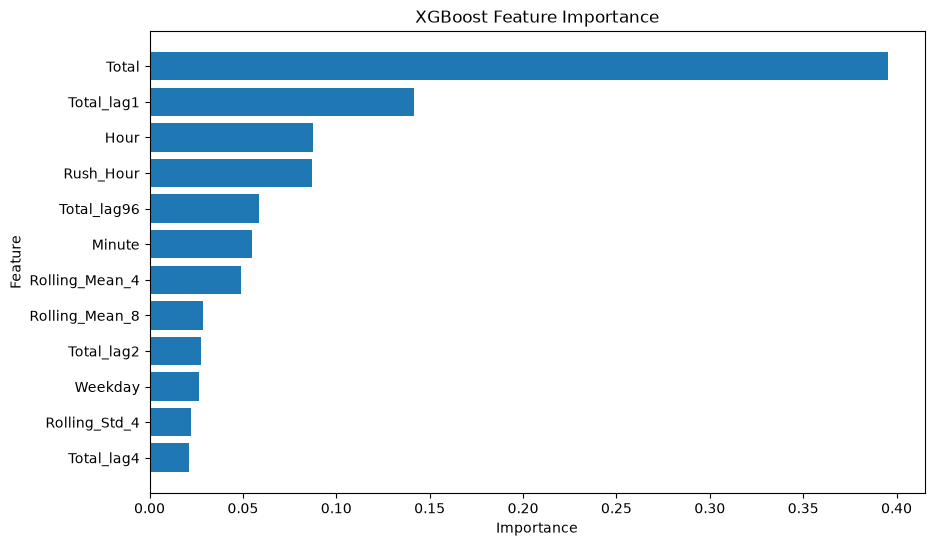

In [100]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()

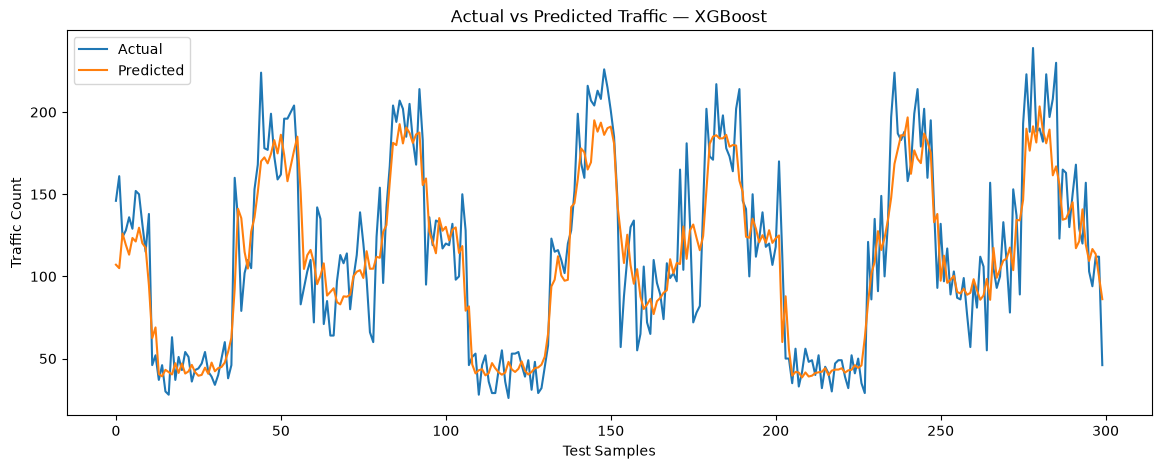

In [101]:
plt.figure(figsize=(14, 5))

plt.plot(
    y_test.values[:300],
    label="Actual"
)

plt.plot(
    xgb_pred[:300],
    label="Predicted"
)

plt.xlabel("Test Samples")
plt.ylabel("Traffic Count")
plt.title("Actual vs Predicted Traffic — XGBoost")
plt.legend()

plt.show()

In [102]:
errors = y_test.values - xgb_pred

print("Mean Error:", errors.mean())
print("Mean Absolute Error:", np.abs(errors).mean())
print("Maximum Error:", np.abs(errors).max())

Mean Error: 3.0543783759582155
Mean Absolute Error: 19.56275412203612
Maximum Error: 137.4103240966797


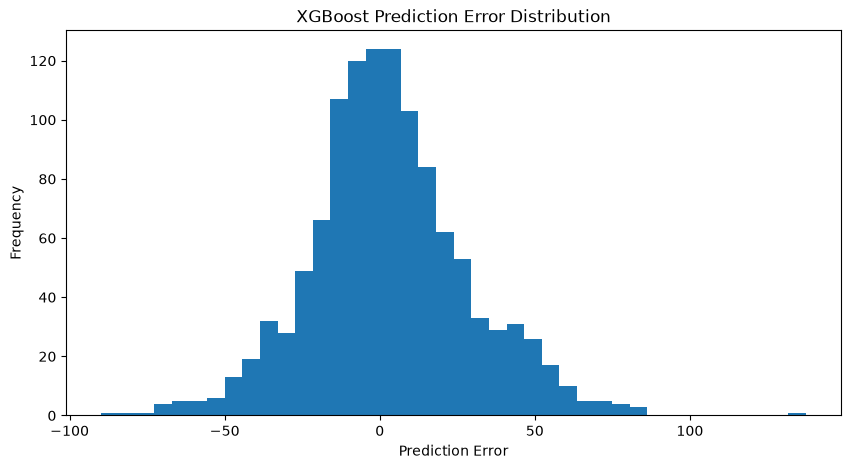

In [103]:
plt.figure(figsize=(10, 5))

plt.hist(errors, bins=40)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("XGBoost Prediction Error Distribution")

plt.show()

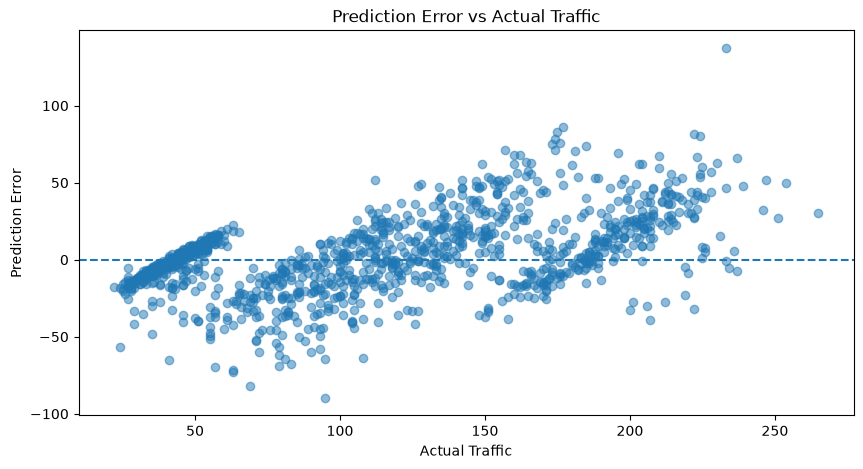

In [104]:
plt.figure(figsize=(10, 5))

plt.scatter(y_test, errors, alpha=0.5)

plt.axhline(0, linestyle="--")

plt.xlabel("Actual Traffic")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs Actual Traffic")

plt.show()

In [105]:
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_pred,
    "Error": errors,
    "Absolute_Error": np.abs(errors)
})

error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual,Predicted,Error,Absolute_Error
536,233.0,95.589676,137.410324,137.410324
657,95.0,184.744385,-89.744385,89.744385
746,177.0,90.789726,86.210274,86.210274
1118,175.0,92.161873,82.838127,82.838127
728,69.0,151.096832,-82.096832,82.096832
715,222.0,140.127426,81.872574,81.872574
811,224.0,143.908997,80.091003,80.091003
937,174.0,95.865120,78.134880,78.134880
457,176.0,99.987160,76.012840,76.012840
361,173.0,97.814758,75.185242,75.185242


In [106]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

In [107]:
tscv = TimeSeriesSplit(n_splits=5)

In [108]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [109]:
xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [200, 300, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best e

In [110]:
print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest CV MAE:")
print(-xgb_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

Best CV MAE:
19.786729596455892


In [111]:
best_xgb = xgb_search.best_estimator_

In [112]:
tuned_xgb_pred = best_xgb.predict(X_test)

In [113]:
tuned_mae = mean_absolute_error(y_test, tuned_xgb_pred)

tuned_rmse = np.sqrt(
    mean_squared_error(y_test, tuned_xgb_pred)
)

tuned_r2 = r2_score(y_test, tuned_xgb_pred)

print("Tuned XGBoost MAE :", tuned_mae)
print("Tuned XGBoost RMSE:", tuned_rmse)
print("Tuned XGBoost R2  :", tuned_r2)

Tuned XGBoost MAE : 19.62382693009739
Tuned XGBoost RMSE: 26.450262048979486
Tuned XGBoost R2  : 0.8035314624011562


In [114]:
print("Previous XGBoost MAE :", xgb_mae)
print("Tuned XGBoost MAE   :", tuned_mae)

print("\nPrevious XGBoost RMSE:", xgb_rmse)
print("Tuned XGBoost RMSE  :", tuned_rmse)

print("\nPrevious XGBoost R2  :", xgb_r2)
print("Tuned XGBoost R2    :", tuned_r2)

Previous XGBoost MAE : 19.56275412203612
Tuned XGBoost MAE   : 19.62382693009739

Previous XGBoost RMSE: 25.974205307080435
Tuned XGBoost RMSE  : 26.450262048979486

Previous XGBoost R2  : 0.81053997407472
Tuned XGBoost R2    : 0.8035314624011562


In [115]:
import joblib

final_model = xgb_model

joblib.dump(final_model, "../models/final_xgb_model.pkl")

['../models/final_xgb_model.pkl']

In [116]:
joblib.dump(features, "../models/feature_list.pkl")

['../models/feature_list.pkl']

In [117]:
import os

print("Model exists:", os.path.exists("../models/final_xgb_model.pkl"))
print("Features exist:", os.path.exists("../models/feature_list.pkl"))

Model exists: True
Features exist: True


In [118]:
features

['Total',
 'Total_lag1',
 'Total_lag2',
 'Total_lag4',
 'Total_lag96',
 'Rolling_Mean_4',
 'Rolling_Mean_8',
 'Rolling_Std_4',
 'Hour',
 'Minute',
 'Weekday',
 'Rush_Hour']

In [119]:
print(len(features))

12


In [120]:
df.groupby("Hour")["Rush_Hour"].first()

Hour
0     0
1     0
2     0
3     0
4     0
5     0
6     1
7     1
8     1
9     1
10    0
11    0
12    0
13    0
14    0
15    0
16    1
17    1
18    1
19    1
20    0
21    0
22    0
23    0
Name: Rush_Hour, dtype: int64

In [121]:
import sys

sys.path.append("../src")

from predict import predict_traffic

In [122]:
test_data = df[
    ["Total", "Hour", "Minute", "Weekday"]
].tail(97).to_dict("records")

In [123]:
prediction = predict_traffic(test_data)

print("Predicted traffic for next 15 minutes:", prediction)

Predicted traffic for next 15 minutes: 42.39596176147461
